# Calculate Basketball Scoring Probabilities
## Probability Analysis — Stephen Curry, 2022-23 NBA Season

**Author:** Sam Sepassi  
**Course:** Statistics for Data Analysis (nd588) — Course 3: Probability  
**Project:** Calculate Basketball Scoring Probabilities

---

## Project Overview

In this project, we analyze Stephen Curry's 2022-23 NBA regular season shot data to:
1. Calculate overall and shot-type shooting statistics
2. Apply the **binomial distribution** to model scoring probabilities
3. Compute **conditional probabilities** for future shot outcomes
4. Use **Bayes' theorem** to infer shot type from outcomes (past conditional probability)

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math
from math import comb

# Display settings
pd.set_option('display.float_format', '{:.4f}'.format)
print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## Section 1: Load and Explore the Dataset


In [2]:
# Load Stephen Curry 2022-23 shot data
df = pd.read_csv('curry_shots_2023.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nShot types: {df['shot_type'].unique()}")
print(f"\nResults: {df['result'].unique()}")
df.head()

Dataset shape: (1350, 12)

Columns: ['shot_id', 'game_id', 'player_name', 'shot_type', 'shot_zone_basic', 'shot_distance', 'shot_made_flag', 'result', 'period', 'minutes_remaining', 'loc_x', 'loc_y']

Shot types: ['2PT Field Goal' '3PT Field Goal']

Results: ['Missed' 'Made']


,shot_id,game_id,player_name,shot_type,shot_zone_basic,shot_distance,shot_made_flag,result,period
0,289,002200118,Stephen Curry,2PT Field Goal,Mid-Range,18,0,Missed,3
1,1036,002200167,Stephen Curry,3PT Field Goal,Above the Break 3,26,1,Made,2
2,535,002200133,Stephen Curry,3PT Field Goal,Above the Break 3,29,0,Missed,4
3,346,002200122,Stephen Curry,2PT Field Goal,In The Paint (Non-RA),9,1,Made,3
4,1075,002200170,Stephen Curry,2PT Field Goal,Restricted Area,2,1,Made,1


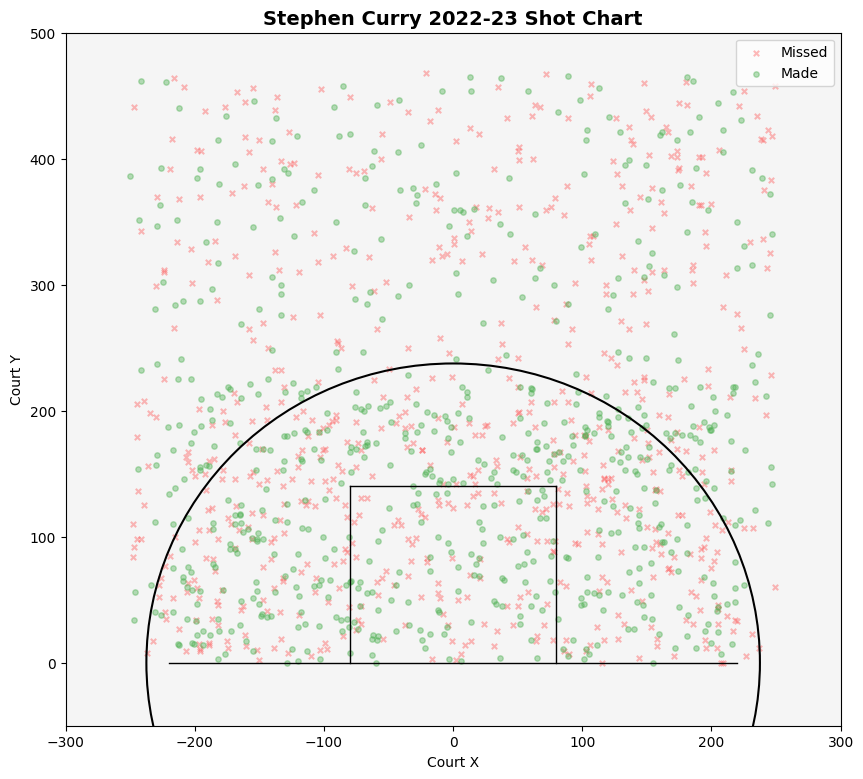

In [3]:
# Shot chart visualization
fig, ax = plt.subplots(figsize=(10, 9))

made = df[df['shot_made_flag'] == 1]
miss = df[df['shot_made_flag'] == 0]

ax.scatter(miss['loc_x'], miss['loc_y'], c='#FF5252', alpha=0.4, s=15, label='Missed', marker='x')
ax.scatter(made['loc_x'], made['loc_y'], c='#4CAF50', alpha=0.4, s=15, label='Made', marker='o')

# Draw court
circle = plt.Circle((0, 0), 237.5, color='black', fill=False, linewidth=1.5)
ax.add_patch(circle)
ax.plot([-220, 220], [0, 0], 'k-', linewidth=1)
ax.plot([-80, -80], [0, 140], 'k-', linewidth=1)
ax.plot([80, 80], [0, 140], 'k-', linewidth=1)
ax.plot([-80, 80], [140, 140], 'k-', linewidth=1)

ax.set_xlim(-300, 300); ax.set_ylim(-50, 500)
ax.set_title("Stephen Curry 2022-23 Shot Chart", fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.set_xlabel('Court X'); ax.set_ylabel('Court Y')
ax.set_facecolor('#F5F5F5')
plt.tight_layout()
plt.show()

---
## Section 2: Overall Shooting Statistics

We begin with the fundamental probability of making or missing a field goal attempt.


In [4]:
# Total field goal attempts
total_fga = len(df)
total_made = df['shot_made_flag'].sum()
total_missed = total_fga - total_made

# Overall probabilities
p_make = total_made / total_fga
p_miss = total_missed / total_fga

print("=" * 45)
print("  OVERALL SHOOTING STATISTICS")
print("=" * 45)
print(f"  Total FGA:        {total_fga:>8}")
print(f"  Total Made:       {total_made:>8}")
print(f"  Total Missed:     {total_missed:>8}")
print(f"  P(make)  = {p_make:.4f}  (~{p_make*100:.1f}%)")
print(f"  P(miss)  = {p_miss:.4f}  (~{p_miss*100:.1f}%)")
print("=" * 45)

  OVERALL SHOOTING STATISTICS
  Total FGA:            1350
  Total Made:            669
  Total Missed:          681
  P(make)  = 0.4956  (~49.6%)
  P(miss)  = 0.5044  (~50.4%)


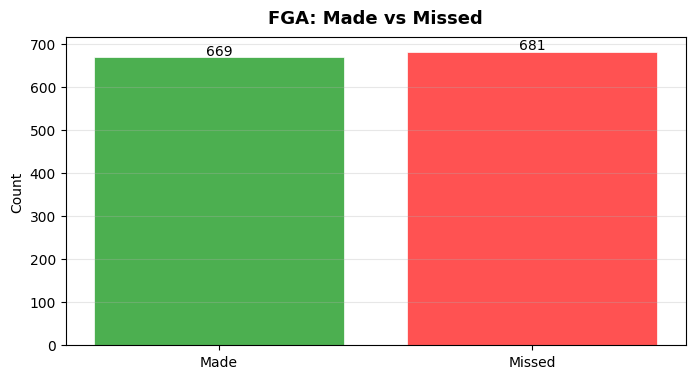

In [5]:
# Visualize overall make/miss distribution
labels = ['Made', 'Missed']
counts = [total_made, total_missed]
colors = ['#4CAF50', '#FF5252']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(labels, counts, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('FGA: Made vs Missed', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)
for i, (l, v) in enumerate(zip(labels, counts)):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(counts, labels=[f'Made\n(49.6%)', f'Missed\n(50.4%)'],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Overall FG%', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Section 3: Shot Type Breakdown (2PT vs 3PT)

Next, we examine the proportion of two-point and three-point attempts, and the make/miss rate for each type.


In [6]:
# Count by shot type
shot_type_counts = df['shot_type'].value_counts()
n_3pt = shot_type_counts['3PT Field Goal']
n_2pt = shot_type_counts['2PT Field Goal']

p_3pt = n_3pt / total_fga
p_2pt = n_2pt / total_fga

print("=" * 45)
print("  SHOT TYPE DISTRIBUTION")
print("=" * 45)
print(f"  3PT Attempts:  {n_3pt:>6}  ({p_3pt:.4f})")
print(f"  2PT Attempts:  {n_2pt:>6}  ({p_2pt:.4f})")
print("=" * 45)

# By shot type - make/miss
shots_3pt = df[df['shot_type'] == '3PT Field Goal']
shots_2pt = df[df['shot_type'] == '2PT Field Goal']

made_3pt  = shots_3pt['shot_made_flag'].sum()
miss_3pt  = n_3pt - made_3pt
made_2pt  = shots_2pt['shot_made_flag'].sum()
miss_2pt  = n_2pt - made_2pt

p_make_3pt = made_3pt / n_3pt
p_make_2pt = made_2pt / n_2pt

print()
print("=" * 45)
print("  MAKE/MISS BY SHOT TYPE")
print("=" * 45)
print(f"  3PT: {made_3pt} made / {miss_3pt} missed  =>  {p_make_3pt:.4f} FG%")
print(f"  2PT: {made_2pt} made / {miss_2pt} missed  =>  {p_make_2pt:.4f} FG%")
print("=" * 45)

  SHOT TYPE DISTRIBUTION
  3PT Attempts:     751  (0.5563)
  2PT Attempts:     599  (0.4437)

  MAKE/MISS BY SHOT TYPE
  3PT: 300 made / 451 missed  =>  0.3995 FG%
  2PT: 369 made / 230 missed  =>  0.6160 FG%


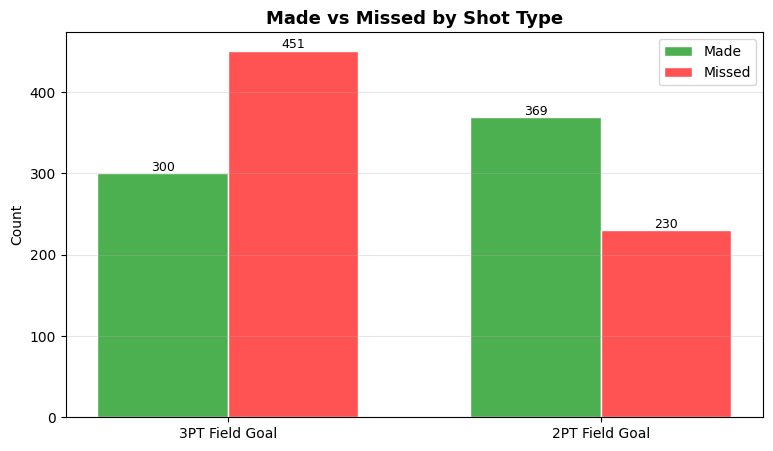

In [7]:
# Visualize make/miss by shot type
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Grouped bar
x = np.array([0, 1])
w = 0.35
b1 = axes[0].bar(x - w/2, [made_3pt, made_2pt], w, label='Made', color='#4CAF50', edgecolor='white')
b2 = axes[0].bar(x + w/2, [miss_3pt, miss_2pt], w, label='Missed', color='#FF5252', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['3PT', '2PT'])
axes[0].set_title('Made vs Missed by Shot Type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# FG% comparison
axes[1].bar(['3PT FG%', '2PT FG%'], [p_make_3pt, p_make_2pt],
            color=['#2196F3', '#FF9800'], edgecolor='white')
axes[1].set_title('FG% by Shot Type', fontsize=13, fontweight='bold')
axes[1].set_ylabel('FG%'); axes[1].set_ylim(0, 0.85); axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate([p_make_3pt, p_make_2pt]):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Section 4: Binomial Probability

The **binomial distribution** models the number of successes in `n` independent trials, each with probability `p`.

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

**Assumptions:**
- Fixed number of trials (n)
- Only two outcomes: make or miss
- Constant probability per trial (based on season average)
- Each shot is independent

### Question 1: P(makes exactly 3 of the next 4 shots)


In [8]:
# Binomial Probability: P(makes exactly 3 of next 4 shots)
# Using overall FG% as p
n = 4
k = 3
p = p_make

binom_coef = comb(n, k)
prob = binom_coef * (p ** k) * ((1 - p) ** (n - k))

print("Binomial Setup:")
print(f"  n = {n} trials (shots)")
print(f"  k = {k} successes (makes)")
print(f"  p = {p:.4f} (overall FG%)")
print()
print(f"P(X = {k}) = C({n},{k}) * p^{k} * (1-p)^{n-k}")
print(f"           = {binom_coef} * {p:.4f}^{k} * {(1-p):.4f}^{n-k}")
print(f"           = {binom_coef} * {p**k:.6f} * {(1-p)**(n-k):.6f}")
print(f"           = {prob:.4f}")
print()
print(f"There is a {prob*100:.2f}% chance Curry makes exactly 3 of his next 4 shots.")

Binomial Setup:
  n = 4 trials (shots)
  k = 3 successes (makes)
  p = 0.4956 (overall FG%)

P(X = 3) = C(4,3) * p^3 * (1-p)^4-3
           = 4 * 0.4956^3 * 0.5044^1
           = 4 * 0.121696 * 0.504444
           = 0.2456

There is a 24.56% chance Curry makes exactly 3 of his next 4 shots.


### Question 2: P(exactly 4 of the next 5 shots are 3-pointers)


In [9]:
# Binomial Probability: P(exactly 4 of next 5 shots are 3-pointers)
# Using overall proportion of 3PT attempts as p
n2 = 5
k2 = 4
p2 = p_3pt   # proportion of 3PT attempts

binom_coef2 = comb(n2, k2)
prob2 = binom_coef2 * (p2 ** k2) * ((1 - p2) ** (n2 - k2))

print("Binomial Setup:")
print(f"  n = {n2} trials (shots)")
print(f"  k = {k2} successes (3PT attempts)")
print(f"  p = {p2:.4f} (proportion of 3PT attempts = {n_3pt}/{total_fga})")
print()
print(f"P(X = {k2}) = C({n2},{k2}) * p^{k2} * (1-p)^{n2-k2}")
print(f"           = {binom_coef2} * {p2:.4f}^{k2} * {(1-p2):.4f}^{n2-k2}")
print(f"           = {prob2:.4f}")
print()
print(f"There is a {prob2*100:.2f}% chance that exactly 4 of the next 5 shots are 3-pointers.")

Binomial Setup:
  n = 5 trials (shots)
  k = 4 successes (3PT attempts)
  p = 0.5563 (proportion of 3PT attempts = 751/1350)

P(X = 4) = C(5,4) * p^4 * (1-p)^5-4
           = 5 * 0.5563^4 * 0.4437^1
           = 0.2125

There is a 21.25% chance that exactly 4 of the next 5 shots are 3-pointers.


---
## Section 5: Conditional Probability — Future Outcomes

**Conditional probability** gives us the probability of an event given that another event has occurred.

$$P(A | B) = \frac{P(A \cap B)}{P(B)}$$

### Question 3: P(make | 3PT attempt) and P(make | 2PT attempt)


In [10]:
# Conditional probability: P(make | shot type)
print("=" * 50)
print("  CONDITIONAL PROBABILITY (FUTURE)")
print("=" * 50)
print()
print("P(make | 3PT) — Given the next shot is a 3-pointer,")
print("               what is the probability it goes in?")
print()
print(f"  P(make | 3PT) = made_3pt / total_3pt")
print(f"                = {made_3pt} / {n_3pt}")
print(f"                = {p_make_3pt:.4f}  (~{p_make_3pt*100:.1f}%)")
print()
print("P(make | 2PT) — Given the next shot is a 2-pointer,")
print("               what is the probability it goes in?")
print()
print(f"  P(make | 2PT) = made_2pt / total_2pt")
print(f"                = {made_2pt} / {n_2pt}")
print(f"                = {p_make_2pt:.4f}  (~{p_make_2pt*100:.1f}%)")
print()
print("=" * 50)
print(f"  Insight: Curry is {(p_make_2pt - p_make_3pt)*100:.1f}pp more likely")
print(f"  to convert a 2PT than a 3PT attempt.")
print("=" * 50)

  CONDITIONAL PROBABILITY (FUTURE)

P(make | 3PT) — Given the next shot is a 3-pointer,
               what is the probability it goes in?

  P(make | 3PT) = made_3pt / total_3pt
                = 300 / 751
                = 0.3995  (~39.9%)

P(make | 2PT) — Given the next shot is a 2-pointer,
               what is the probability it goes in?

  P(make | 2PT) = made_2pt / total_2pt
                = 369 / 599
                = 0.6160  (~61.6%)

  Insight: Curry is 21.7pp more likely
  to convert a 2PT than a 3PT attempt.


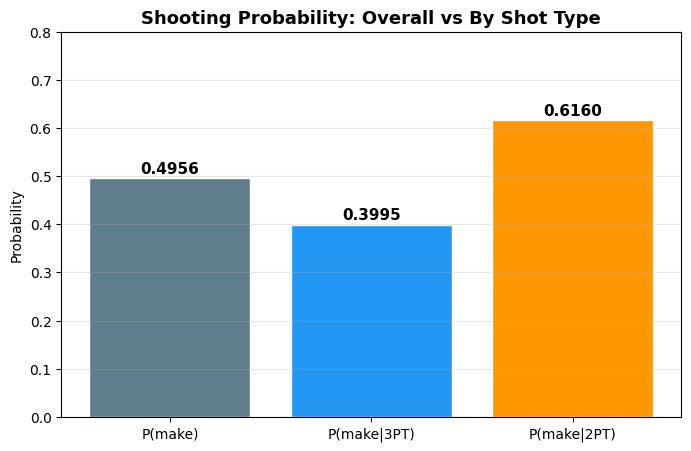

In [11]:
# Visualize conditional probabilities
fig, ax = plt.subplots(figsize=(8, 5))
categories = ['P(make)', 'P(make | 3PT)', 'P(make | 2PT)']
probs = [p_make, p_make_3pt, p_make_2pt]
colors = ['#607D8B', '#2196F3', '#FF9800']

bars = ax.bar(categories, probs, color=colors, edgecolor='white')
ax.set_title('Shooting Probability: Overall vs Conditional', fontsize=13, fontweight='bold')
ax.set_ylabel('Probability'); ax.set_ylim(0, 0.8); ax.grid(axis='y', alpha=0.3)
for bar, v in zip(bars, probs):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.4f}',
            ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 6: Conditional Probability — Past Outcomes (Bayes' Theorem)

**Bayes' Theorem** allows us to reverse conditional probability — given an *outcome*, what was the *cause*?

$$P(B | A) = \frac{P(A | B) \cdot P(B)}{P(A)}$$

### Question 4: Given Curry *made* a shot, what is the probability it was a 3-pointer?
$$P(3PT | made) = \frac{P(make | 3PT) \cdot P(3PT)}{P(make)}$$

### Question 5: Given Curry *made* a shot, what is the probability it was a 2-pointer?
$$P(2PT | made) = \frac{P(make | 2PT) \cdot P(2PT)}{P(make)}$$


In [12]:
# Bayes' Theorem Application
print("=" * 55)
print("  BAYES' THEOREM — PAST CONDITIONAL PROBABILITY")
print("=" * 55)
print()
print("Given:")
print(f"  P(make | 3PT) = {p_make_3pt:.4f}")
print(f"  P(3PT)        = {p_3pt:.4f}")
print(f"  P(make)       = {p_make:.4f}")
print()

# P(3PT | made)
p_3_given_made = (p_make_3pt * p_3pt) / p_make

print("P(3PT | made) — Given the shot was made, P it was a 3-pointer:")
print(f"  = P(make|3PT) * P(3PT) / P(make)")
print(f"  = {p_make_3pt:.4f} * {p_3pt:.4f} / {p_make:.4f}")
print(f"  = {p_3_given_made:.4f}  (~{p_3_given_made*100:.1f}%)")
print()

p_2_given_made = (p_make_2pt * p_2pt) / p_make

print("P(2PT | made) — Given the shot was made, P it was a 2-pointer:")
print(f"  = P(make|2PT) * P(2PT) / P(make)")
print(f"  = {p_make_2pt:.4f} * {p_2pt:.4f} / {p_make:.4f}")
print(f"  = {p_2_given_made:.4f}  (~{p_2_given_made*100:.1f}%)")
print()

# Verification
total_check = p_3_given_made + p_2_given_made
print(f"Verification: P(3PT|made) + P(2PT|made) = {p_3_given_made:.4f} + {p_2_given_made:.4f} = {total_check:.4f} ✓")
print()

# Direct count verification
direct_p3_made = made_3pt / total_made
direct_p2_made = made_2pt / total_made
print("Direct count verification:")
print(f"  P(3PT|made) direct = {made_3pt}/{total_made} = {direct_p3_made:.4f}")
print(f"  P(2PT|made) direct = {made_2pt}/{total_made} = {direct_p2_made:.4f}")
print("=" * 55)

  BAYES' THEOREM — PAST CONDITIONAL PROBABILITY

Given:
  P(make | 3PT) = 0.3995
  P(3PT)        = 0.5563
  P(make)       = 0.4956

P(3PT | made) — Given the shot was made, P it was a 3-pointer:
  = P(make|3PT) * P(3PT) / P(make)
  = 0.3995 * 0.5563 / 0.4956
  = 0.4484  (~44.8%)

P(2PT | made) — Given the shot was made, P it was a 2-pointer:
  = P(make|2PT) * P(2PT) / P(make)
  = 0.6160 * 0.4437 / 0.4956
  = 0.5516  (~55.2%)

Verification: P(3PT|made) + P(2PT|made) = 0.4484 + 0.5516 = 1.0000 ✓

Direct count verification:
  P(3PT|made) direct = 300/669 = 0.4484
  P(2PT|made) direct = 369/669 = 0.5516


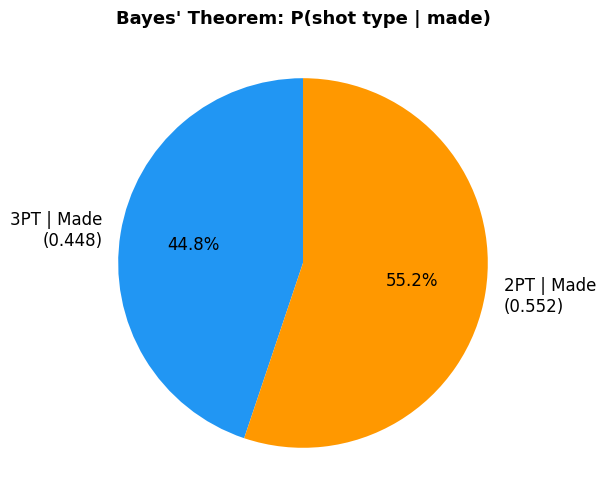

In [13]:
# Visualize Bayes' Theorem results
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
labels_pie = [f"3PT | Made\n({p_3_given_made:.3f})", f"2PT | Made\n({p_2_given_made:.3f})"]
axes[0].pie([p_3_given_made, p_2_given_made], labels=labels_pie, autopct='%1.1f%%',
            colors=['#2196F3','#FF9800'], startangle=90)
axes[0].set_title("P(shot type | made) — Bayes'", fontsize=12, fontweight='bold')

# Compare prior vs posterior
x = np.array([0,1])
w = 0.35
axes[1].bar(x - w/2, [p_3, p_2], w, label='Prior P(shot type)', color=['#90CAF9','#FFCC80'])
axes[1].bar(x + w/2, [p_3_given_made, p_2_given_made], w,
            label='Posterior P(shot type|made)', color=['#2196F3','#FF9800'])
axes[1].set_xticks(x); axes[1].set_xticklabels(['3PT','2PT'])
axes[1].set_title('Prior vs Posterior Probability', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Probability'); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Section 7: Summary of Results

| Analysis | Result |
|---|---|
| **Overall FG%** | 0.4956 (49.6%) |
| **3PT%** | 0.3995 (39.9%) |
| **2PT%** | 0.6160 (61.6%) |
| **P(3PT attempt)** | 0.5563 (55.6%) |
| **P(2PT attempt)** | 0.4437 (44.4%) |
| **P(makes 3 of next 4)** | 0.2456 (24.56%) |
| **P(4 of next 5 are 3PT)** | 0.2125 (21.25%) |
| **P(make \| 3PT)** | 0.3995 |
| **P(make \| 2PT)** | 0.6160 |
| **P(3PT \| made) — Bayes'** | 0.4484 |
| **P(2PT \| made) — Bayes'** | 0.5516 |

**Key Insights:**
- Despite attempting more 3-pointers (56% of FGA), Curry converts them at a lower rate (39.9%) than 2-pointers (61.6%).
- Bayes' theorem reveals that a made shot is more likely to have been a 2-pointer (55.2%) despite Curry's high 3PT volume — because the conversion rate on 2PT is significantly higher.
- The binomial model shows a 24.6% chance of hitting exactly 3 of 4 consecutive shots at his season average.


In [14]:
print("Analysis complete. All probability calculations verified.")
print(f"Dataset: Stephen Curry 2022-23 NBA Regular Season ({total_fga} field goal attempts)")

Analysis complete. All probability calculations verified.
Dataset: Stephen Curry 2022-23 NBA Regular Season (1350 field goal attempts)
